In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Проверяем формат столбцов

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [6]:
sales_by_date = df.groupby('Дата').size().reset_index(name='Количество_продаж')

print(sales_by_date)

          Дата  Количество_продаж
0   2018-01-04               1840
1   2018-01-05               1301
2   2018-01-06               1306
3   2018-01-07               1322
4   2018-01-09               1719
..         ...                ...
200 2018-08-26               1462
201 2018-08-28               1731
202 2018-08-29               1497
203 2018-08-30               1445
204 2018-08-31               1366

[205 rows x 2 columns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество_продаж')

Вывести несколько первых строк сгруппированных данных

In [8]:
print(grouped_df.head())

        Дата  Количество_продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Нарисуйте график продаж у `grouped_df`

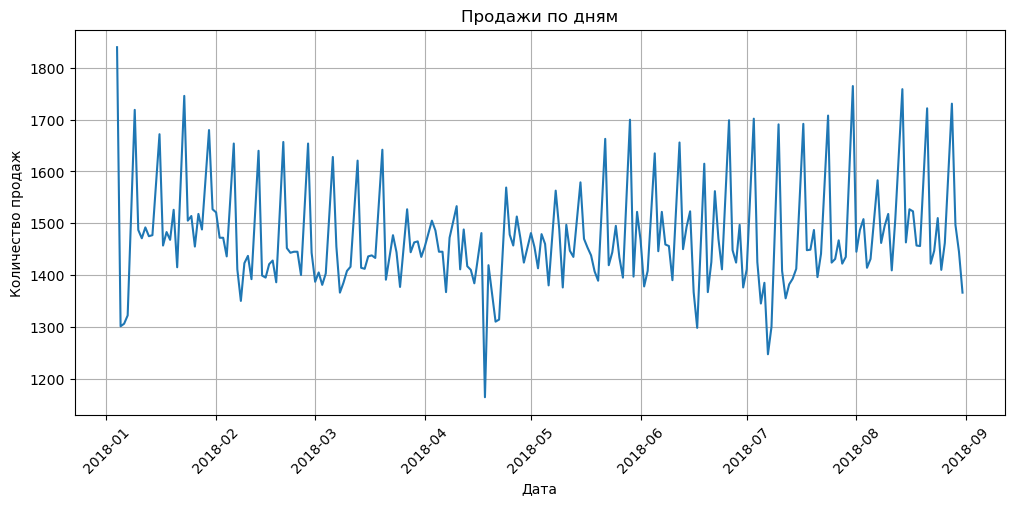

In [9]:
plt.figure(figsize=(12,5))

plt.plot(grouped_df['Дата'], grouped_df['Количество_продаж'])

plt.title('Продажи по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
#На графике продаж по дням наблюдается колеблющаяся динамика. В отдельные даты фиксируются выраженные пики продаж, что может быть связано с разовыми всплесками спроса или внешними факторами.

#Общий тренд не демонстрирует устойчивого роста или падения, продажи остаются относительно стабильными, но с высокой вариативностью между днями.

#Также присутствуют периоды сниженной активности, что может указывать на неравномерность спроса или особенности операционной деятельности.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
col = 'Количество'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(outliers)

             Дата  Склад   Контрагент Номенклатура  Количество
3      2018-01-04      1    address_0    product_3          10
59     2018-01-04      1    address_3    product_6          10
142    2018-01-04      1   address_10    product_2          10
175    2018-01-04      1   address_14    product_1           9
176    2018-01-04      1   address_14    product_2          10
...           ...    ...          ...          ...         ...
301309 2018-08-31      5  address_169    product_0          10
301310 2018-08-31      5  address_169    product_1          20
301311 2018-08-31      5  address_169    product_2          15
301312 2018-08-31      5  address_169    product_3          10
301315 2018-08-31      5  address_169    product_6          15

[13140 rows x 5 columns]


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
df['Дата'] = pd.to_datetime(df['Дата'])

df = df[df['Дата'].dt.month.isin([6, 7, 8])]

df = df[df['Дата'].dt.weekday == 2]

df = df[df['Склад'].isin([1, 2, 3])]

top_product = (
    df.groupby('Номенклатура')['Количество']
    .sum()
    .reset_index()
    .sort_values('Количество', ascending=False)
)

print(top_product.head(1))

  Номенклатура  Количество
1    product_1        8135


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [19]:
#Когда скачал CSV файл с погодой, значения с температурой эксель посчитал как дату. Честно я так и не смог вернуть обратно значения в цифры. Что только не перепробовал. Я не знаю как это решить 

UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 0-1: invalid continuation byte